✅ Data successfully loaded and cleaned!
Total Records: 5000 | Total Columns: 17

📊 Generating Bar Chart for Top 10 COVID-19 Confirmed Cases...


C:\Users\Admin\AppData\Local\Temp\ipykernel_11056\2400855049.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


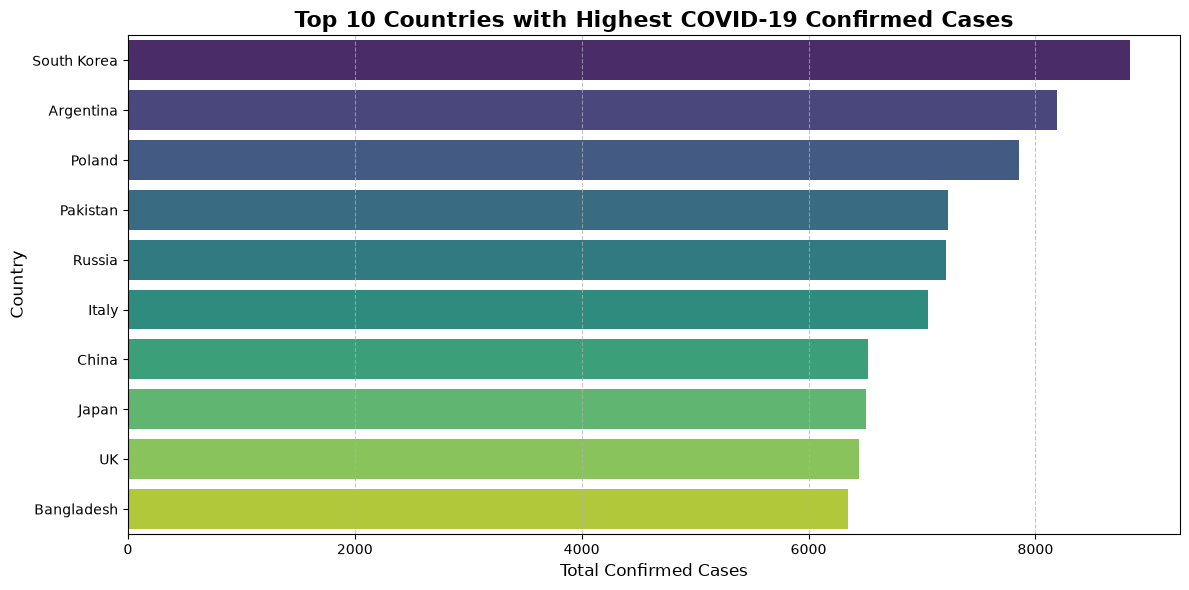

In [1]:
# --- LIBRARIES IMPORT ---
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. LOAD THE DATASET ---
file_name = "covid_data.csv"
current_dir = os.getcwd()
full_path = os.path.join(current_dir, file_name)

if not os.path.exists(full_path):
    raise FileNotFoundError(
        f"Error: The file '{file_name}' was not found at {full_path}."
    )

df = pd.read_csv(full_path)

# --- 2. DATA CLEANING & PREPARATION ---
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df = df.sort_values(by="Date").reset_index(drop=True)
df["State_Province"] = df["State_Province"].fillna("Not Specified")

print("✅ Data successfully loaded and cleaned!")
print(f"Total Records: {df.shape[0]} | Total Columns: {df.shape[1]}\n")

# --- 3. DATA AGGREGATION ---

country_data = df.groupby("Country")["Confirmed_Cases"].max().reset_index()
top_10_countries = country_data.sort_values(by="Confirmed_Cases", ascending=False).head(10)

# --- 4. VISUALIZATION: Matplotlib & Seaborn  ---
print("📊 Generating Bar Chart for Top 10 COVID-19 Confirmed Cases...")


plt.figure(figsize=(12, 6))


sns.barplot(
    x="Confirmed_Cases", 
    y="Country", 
    data=top_10_countries, 
    palette="viridis"
)


plt.title("Top 10 Countries with Highest COVID-19 Confirmed Cases", fontsize=16, fontweight='bold')
plt.xlabel("Total Confirmed Cases", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()